# Feature Engineering

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from preprocessing import load_and_clean
from feature_engineering import add_engineered_features, ALL_FEATURE_COLS

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

df = load_and_clean()
X  = add_engineered_features(df)
y  = df['Total Wait Time (min)']

print(f'Total features: {X.shape[1]}')
print(X.columns.tolist())

Total features: 16
['Urgency Level', 'Time of Day', 'Day of Week', 'Season', 'Region', 'Nurse-to-Patient Ratio', 'Specialist Availability', 'Facility Size (Beds)', 'Is Weekend', 'Hour', 'Nurse Load', 'Is Peak Hour', 'Resource Pressure', 'Urgency x Time', 'Urgency x Weekend', 'Large Facility']


## 1. New Engineered Features Preview

In [2]:
engineered = ['Nurse Load', 'Is Peak Hour', 'Resource Pressure',
              'Urgency x Time', 'Urgency x Weekend', 'Large Facility']

X[engineered].describe().round(3)

,Nurse Load,Is Peak Hour,Resource Pressure,Urgency x Time,Urgency x Weekend,Large Facility
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,0.263,0.645,0.023,8.038,0.709,0.414
std,0.102,0.478,0.026,4.699,1.272,0.493
min,0.167,0.000,0.003,1.000,0.000,0.000
25%,0.200,0.000,0.007,4.000,0.000,0.000
50%,0.250,1.000,0.015,8.000,0.000,0.000
75%,0.250,1.000,0.028,12.000,1.000,1.000
max,0.500,1.000,0.209,20.000,4.000,1.000


## 2. Correlation of All Features with Wait Time

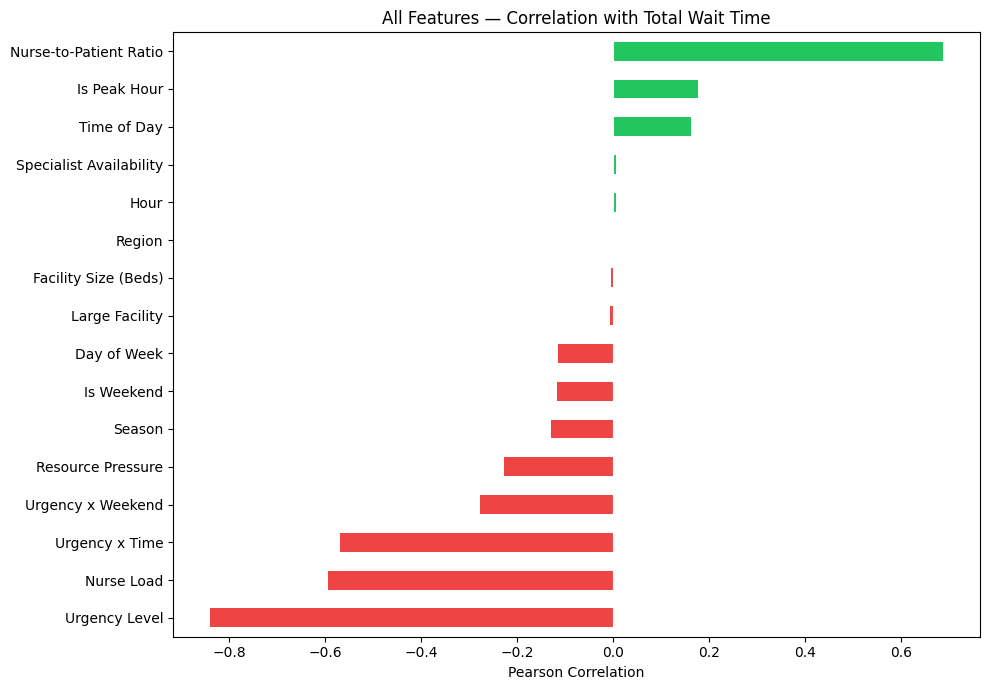

Urgency Level             -0.841
Nurse Load                -0.594
Urgency x Time            -0.570
Urgency x Weekend         -0.278
Resource Pressure         -0.228
Season                    -0.129
Is Weekend                -0.117
Day of Week               -0.116
Large Facility            -0.007
Facility Size (Beds)      -0.004
Region                     0.001
Hour                       0.005
Specialist Availability    0.007
Time of Day                0.162
Is Peak Hour               0.176
Nurse-to-Patient Ratio     0.688
dtype: float64


In [3]:
corr = X.corrwith(y).sort_values()

colors = ['#ef4444' if v < 0 else '#22c55e' for v in corr.values]
corr.plot(kind='barh', color=colors, figsize=(10, 7))
plt.axvline(0, color='white', linewidth=0.8)
plt.title('All Features — Correlation with Total Wait Time')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print(corr.round(3))

## 3. Resource Pressure vs Wait Time

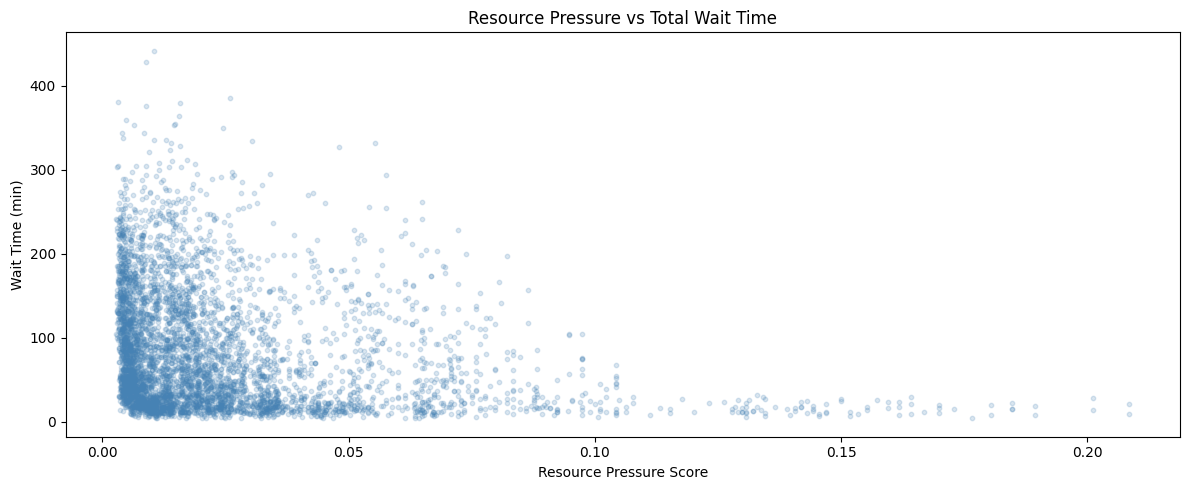

In [4]:
plt.scatter(X['Resource Pressure'], y, alpha=0.2, color='steelblue', s=10)
plt.title('Resource Pressure vs Total Wait Time')
plt.xlabel('Resource Pressure Score')
plt.ylabel('Wait Time (min)')
plt.tight_layout()
plt.show()

## 4. Peak Hour Impact

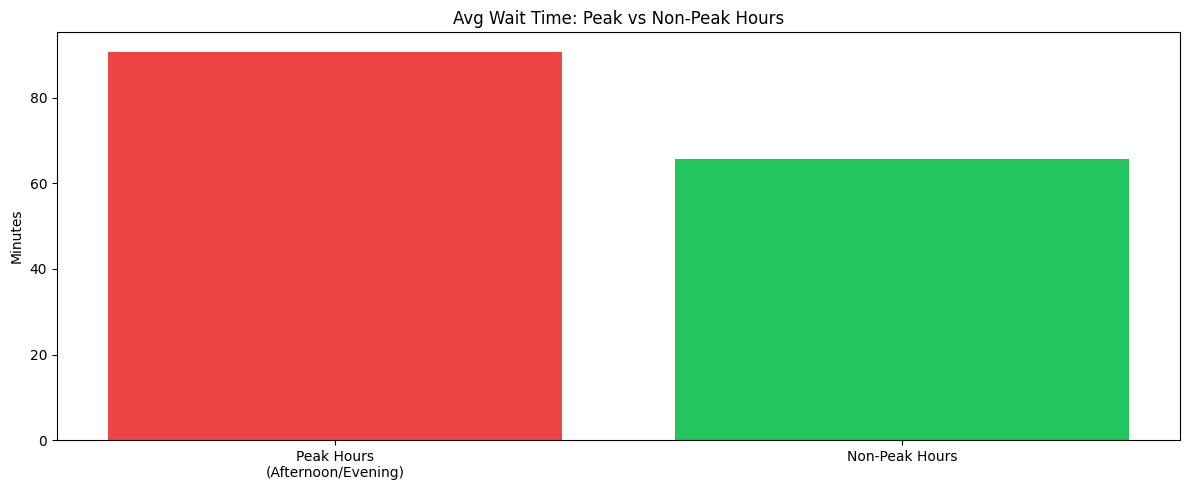

Peak hour avg wait:     90.8 min
Non-peak hour avg wait: 65.8 min
Difference:             25.0 min


In [5]:
peak_avg    = y[X['Is Peak Hour'] == 1].mean()
nonpeak_avg = y[X['Is Peak Hour'] == 0].mean()

plt.bar(['Peak Hours\n(Afternoon/Evening)', 'Non-Peak Hours'],
        [peak_avg, nonpeak_avg],
        color=['#ef4444', '#22c55e'])
plt.title('Avg Wait Time: Peak vs Non-Peak Hours')
plt.ylabel('Minutes')
plt.tight_layout()
plt.show()

print(f'Peak hour avg wait:     {peak_avg:.1f} min')
print(f'Non-peak hour avg wait: {nonpeak_avg:.1f} min')
print(f'Difference:             {peak_avg - nonpeak_avg:.1f} min')

## 5. Urgency x Time Interaction

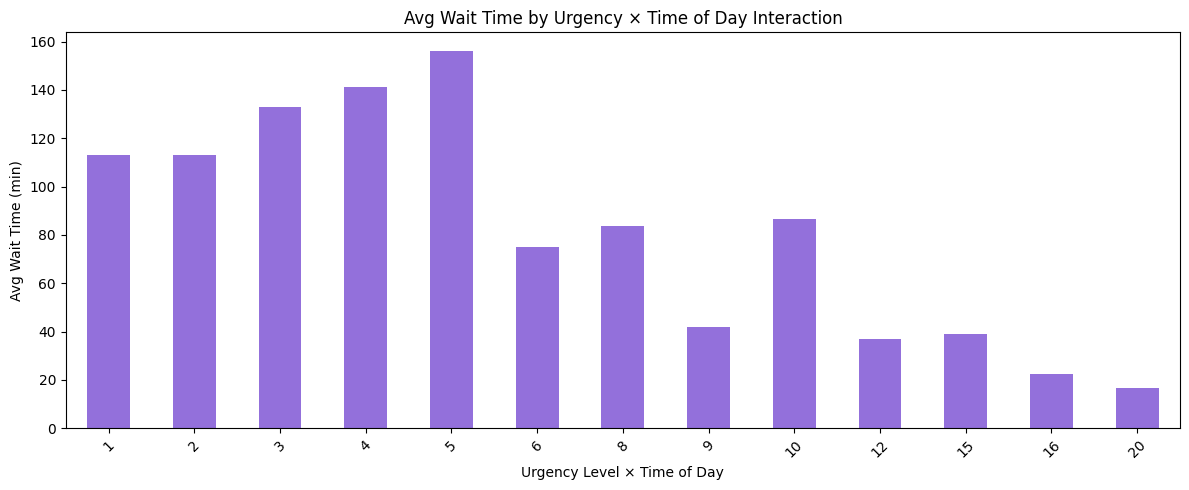

In [6]:
temp = pd.DataFrame({
    'Urgency x Time': X['Urgency x Time'],
    'Wait Time': y
})

grouped = temp.groupby('Urgency x Time')['Wait Time'].mean()

grouped.plot(kind='bar', color='mediumpurple')
plt.title('Avg Wait Time by Urgency × Time of Day Interaction')
plt.xlabel('Urgency Level × Time of Day')
plt.ylabel('Avg Wait Time (min)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Feature Correlation Heatmap (All Features)

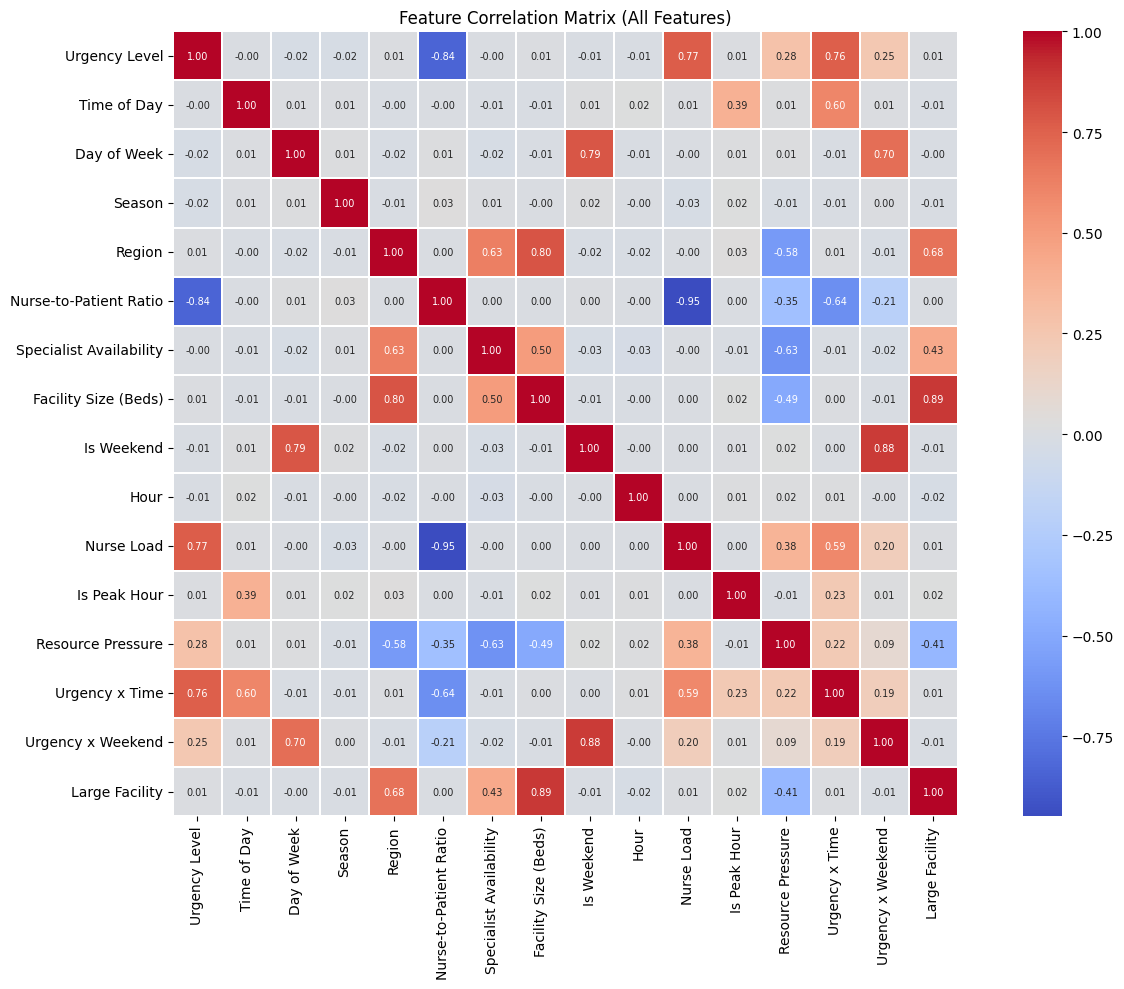

In [7]:
plt.figure(figsize=(14, 10))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.3, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix (All Features)')
plt.tight_layout()
plt.show()

## 7. Final Feature Summary

In [8]:
summary = pd.DataFrame({
    'Feature': X.columns,
    'Corr with Wait Time': X.corrwith(y).values,
    'Mean': X.mean().values,
    'Std': X.std().values,
}).set_index('Feature').sort_values('Corr with Wait Time')

print(summary.round(3).to_string())

                         Corr with Wait Time    Mean     Std
Feature                                                     
Urgency Level                         -0.841   2.501   1.112
Nurse Load                            -0.594   0.263   0.102
Urgency x Time                        -0.570   8.038   4.699
Urgency x Weekend                     -0.278   0.709   1.272
Resource Pressure                     -0.228   0.023   0.026
Season                                -0.129   2.498   1.117
Is Weekend                            -0.117   0.285   0.452
Day of Week                           -0.116   3.960   2.028
Large Facility                        -0.007   0.414   0.493
Facility Size (Beds)                  -0.004  87.119  57.999
Region                                 0.001   0.601   0.490
Hour                                   0.005  11.499   6.889
Specialist Availability                0.007   3.875   3.043
Time of Day                            0.162   3.214   1.121
Is Peak Hour            